In [6]:
# 이전 실습에서 만들어진 모델로 새로운 이미지 분류 예측
# 새로운 이미지도 크기 조정(150, 150) + 스캐일링
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

MODEL_PATH = 'catdog_best.keras'
IMAGE_HEIGHT, IMG_WIDTH = 150, 150
THRESH = 0.5    # 시그모이드 임계값 (0.4 ~ 0.6 사이로 조정가능)

idx_to_name = {0: 'cat', 1: 'dog'}

# model
model = tf.keras.models.load_model(MODEL_PATH)
print(model.summary())




Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 148, 148, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 74, 74, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 74, 74, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 37, 37, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 37, 37, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │    10,617,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,924,325 (121.78 MB)

 Trainable params: 10,641,441 (40.59 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 21,282,884 (81.19 MB)

None


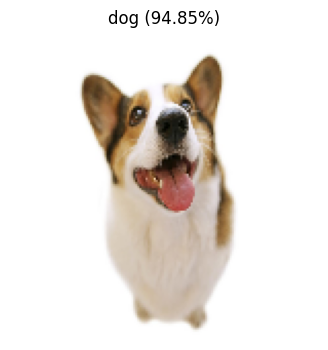

('dog', 0.9484536647796631)


In [16]:
# 전처리 함수
def preprocess_imageFunc(image_path):
  img = tf.keras.preprocessing.image.load_img(image_path, target_size=(IMAGE_HEIGHT, IMG_WIDTH))
  arr = tf.keras.utils.img_to_array(img)
  arr = arr / 255
  arr = np.expand_dims(arr, axis=0)
  return arr

# 단일 이미지 예측함수
def predict_oneFunc(image_path, show=True):
  x = preprocess_imageFunc(image_path)
  prob_dog = float(model.predict(x, verbose=0)[0][0]) # 시그모이드 출력

  if prob_dog > THRESH:
    pred_name = idx_to_name[1] # dog
    prob_of_predicted_class = prob_dog
  else:
    pred_name = idx_to_name[0] # cat
    prob_of_predicted_class = 1 - prob_dog

  if show:
    img_disp = tf.keras.utils.load_img(image_path, target_size=(IMAGE_HEIGHT, IMG_WIDTH))
    plt.figure(figsize=(4,4))
    plt.imshow(img_disp)
    plt.axis('off')
    plt.title(f'{pred_name} ({prob_of_predicted_class*100:.2f}%)')
    plt.show()

  return pred_name, prob_of_predicted_class


res  = predict_oneFunc('tiger1.jpg', show=True)
print(res)